### 🌊 LangChain 스트리밍 

LLM의 답변을 한 번에 다 받는 게 아니라, **토큰이 생성되는 대로 실시간으로** 받는 방법을
가장 단순한 형태로 정리했습니다.

사용하는 모델 : `gpt-4o-mini` 하나

> ⚠️ Jupyter는 자체 이벤트 루프를 실행 중이라 `asyncio.run()`을 쓰면 오류가 납니다.<br>
> 그래서 아래 예제는 셀에서 바로 `await`를 사용합니다.

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")

---

`.invoke()`는 완성된 답변 전체를 한 번에 돌려주지만<br> 
`.stream()`과 `.astream()`은 **생성되는 토큰을 하나씩** 돌려줍니다.

### 1. 기본 스트리밍 — 동기 `llm.stream()`

`for`로 순회하면서 바로 출력하면 글자가 흘러나오는 효과를 낼 수 있습니다.

In [ ]:
for chunk in llm.stream("파이썬의 장점을 3가지 알려줘"): #stream와다다다
    print(chunk.content, end="", flush=True)
    #stream은 동기/ astream은 비동기임
    #그 다음 토큰이 들어오기 전에 시간이 남으면, 다른 일을 할 수 있는 것임

파이썬의 장점은 다음과 같습니다:

1. **가독성 높은 문법**: 파이썬은 다른 프로그래밍 언어에 비해 문법이 간결하고 명확하여 코드의 가독성이 높습니다. 이는 개발자가 코드를 작성하고 유지보수하는 데 큰 도움이 됩니다. 또한, 새로운 프로그래머가 배우기 쉽게 설계되어 있어 입문자에게 적합합니다.

2. **광범위한 라이브러리와 프레임워크**: 파이썬은 데이터 분석, 웹 개발, 인공지능, 머신러닝 등 다양한 분야에서 사용할 수 있는 많은 라이브러리와 프레임워크를 보유하고 있습니다. 예를 들어, NumPy, Pandas, TensorFlow, Django 등이 있어 각종 프로젝트와 연구에 효과적으로 활용할 수 있습니다.

3. **활발한 커뮤니티**: 파이썬은 전 세계적으로 큰 사용자 커뮤니티를 가지고 있어, 최신 정보와 자료를 쉽게 찾아볼 수 있습니다. 이 덕분에 문제 해결을 위한 지원을 받거나 다양한 교육 자료와 예제를 확보하기 용이해 많은 개발자들이 파이썬을 선호합니다.

### 1. 기본 스트리밍 — 비동기 `llm.astream()`

`async for`로 순회하면서 바로 출력하면 글자가 흘러나오는 효과를 낼 수 있습니다.

In [4]:
async for chunk in llm.astream("파이썬의 장점을 3가지 알려줘"):
    print(chunk.content, end="", flush=True)

파이썬의 장점은 여러 가지가 있지만, 그중에서 특히 중요한 3가지를 소개하겠습니다.

1. **간결하고 읽기 쉬운 문법**:
   파이썬은 코드가 간결하고 직관적이기 때문에 배우기 쉽고 이해하기가 용이합니다. 이는 특히 프로그래밍 초보자에게 큰 장점이 됩니다. 코드의 가독성이 높아 유지보수 및 협업을 하는 데에도 유리합니다.

2. **풍부한 라이브러리와 프레임워크**:
   파이썬은 다양한 분야에서 활용될 수 있는 방대한 라이브러리와 프레임워크를 제공합니다. 데이터 분석(Numpy, Pandas), 웹 개발(Django, Flask), 인공지능(TensorFlow, PyTorch) 등 여러 분야에서 유용하게 사용됩니다. 이를 통해 개발자들은 복잡한 기능을 손쉽게 구현할 수 있습니다.

3. **활발한 커뮤니티와 지원**:
   파이썬은 전 세계적으로 활발한 사용자 커뮤니티를 가지고 있어, 다양한 자료와 튜토리얼, 지원을 쉽게 찾을 수 있습니다. 문제에 부딪혔을 때 도움을 받을 수 있는 자원이 풍부하다는 것은 개발자에게 큰 장점입니다.

이 외에도 파이썬은 다양한 플랫폼에서 실행 가능하고, 객체 지향 프로그래밍을 지원하는 등 많은 장점을 가지고 있습니다.

#### **llm.astream()**
이름의 a는 Asynchronous(비동기)의 약자입니다. AI가 다음 토큰을 생성하는 데 걸리는 미세한 대기 시간 동안, <br> 프로그램이 멈추지 않고 다른 유저의 요청이나 다른 이벤트를 동시에 처리할 수 있도록 길을 열어줍니다.

[ 호출 방식 ] **async for chunk in llm.astream("질문"):** 처럼 async for 문을 사용하며, <br>
              호출하는 함수 앞에 **async def**가 붙어야 합니다.

작동: 토큰이 나오는 순간에만 잠깐 켜져서 처리하고, 토큰을 기다리는 중에는 제어권을 컴퓨터 시스템에 반납합니다.

적합한 곳: 웹 서버(FastAPI, Django 등). 동시에 수십, 수백 명의 유저가 접속해서 챗봇을 쓸 때 서버가 마비되지 않으려면 반드시 astream을 써야 합니다.

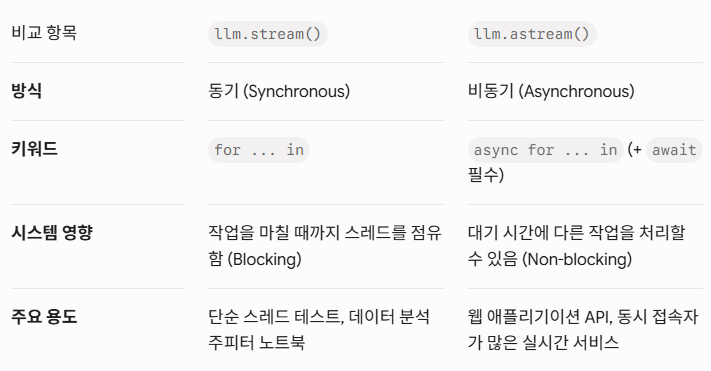

---

### 2. 프롬프트 템플릿과 함께 스트리밍하기

실제로는 모델 하나만 쓰기보다 `프롬프트 | 모델 | 출력파서`로 이어진 체인을 씁니다. <br>
이 체인도 그대로 `.astream()`으로 스트리밍할 수 있습니다. `StrOutputParser()`를 거치면<br>
각 조각이 `AIMessageChunk`가 아니라 이미 **문자열**로 나옵니다.

In [5]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

prompt = ChatPromptTemplate.from_messages([
    ("system", "당신은 친절한 IT 강사입니다. 핵심만 간결하게 설명하세요."),
    ("human", "{question}"),
])
chain = prompt | llm | StrOutputParser()

async for chunk in chain.astream({"question": "비동기 프로그래밍이 왜 필요한가요?"}):
    print(chunk, end="", flush=True)  # 이미 문자열이므로 .content가 필요 없습니다


비동기 프로그래밍은 다음과 같은 이유로 필요합니다:

1. **효율성**: 비동기 방식으로 작업이 진행되면, 다른 작업이 동시에 수행될 수 있어 자원을 효율적으로 사용할 수 있습니다.

2. **사용자 경험 향상**: 긴 작업(예: 네트워크 요청)이 진행되는 동안 UI가 멈추지 않게 하여 사용자에게 원활한 경험을 제공합니다.

3. **리소스 절약**: I/O 작업이 많은 프로그램에서 실행 대기 시간이 줄어들어 서버 리소스를 절약할 수 있습니다.

4. **확장성**: 동시 작업을 처리할 수 있어 서버의 성능을 높이고 더 많은 사용자 요청을 처리할 수 있게 합니다. 

비동기 프로그래밍은 특히 웹 개발 및 네트워킹 환경에서 매우 중요합니다.

---

## 정리

| 방법 | 언제 쓰나 |
|---|---|
| `llm.astream(질문)` | 모델 하나에 바로 물어보고 스트리밍 |
| `chain.astream({...})` | 프롬프트 템플릿까지 포함한 체인을 스트리밍 |

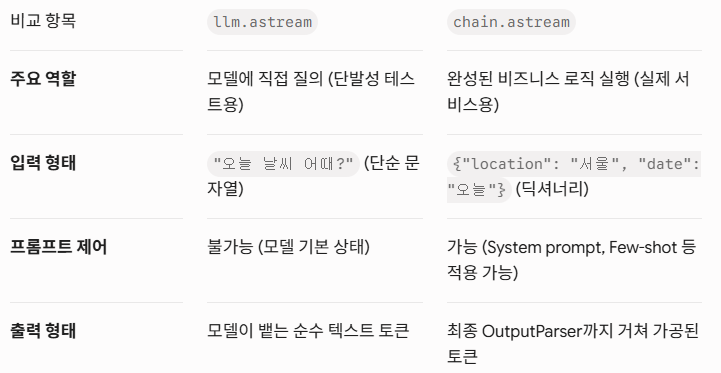